In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'August21'

Load the tensorboard log files into pandas dataframe

In [3]:
# Gather data
data = []
logs = glob.glob(rf".\logs\wheeled_random_beocat_Aug21\*\*")
for log in logs:
    experiment_info = log.split('\\')[-2].split('_')
    algorithm = experiment_info[0]
    st = experiment_info[1]
    # print(log)
    print(log.split('\\'))
    print(experiment_info)

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)
df.to_csv(rf"results\wheeled_random_raw_beocat_{date}.csv")
df

['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set1_0', 'events.out.tfevents.1755616997.wizard37.3740347.0']
['A2C', 'set1', '0']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set1_0', 'events.out.tfevents.1755625638.warlock25.2882412.0']
['A2C', 'set1', '0']
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set2_0', 'events.out.tfevents.1755616997.wizard17.3302973.0']
['A2C', 'set2', '0']
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set3_0', 'events.out.tfevents.1755616997.wizard18.1493420.0']
['A2C', 'set3', '0']
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set4_0', 'events.out.tfevents.1755616997.dwarf33.1373591.0']
['A2C', 'set4', '0']
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set5_0', 'events.out.tfevents.1755616997.dwarf33.1373592.0']
['A2C', 'set5', '0']
['.', 'logs', 'wheeled_random_beocat_Aug21', 'A2C_set6_0', 'events.out.tfevents.1755618052.warlock32.35533.0']
['A2C'

,algorithm,set,step,reward
0,A2C,set1,2000,-89263.390625
1,A2C,set1,4000,-88692.328125
2,A2C,set1,6000,-80913.742188
3,A2C,set1,8000,-78909.929688
4,A2C,set1,10000,-76183.390625
...,...,...,...,...
86253,TRPO,set8,4984832,-47485.699219
86254,TRPO,set8,4988928,-48588.933594
86255,TRPO,set8,4993024,-46780.234375
86256,TRPO,set8,4997120,-44793.050781


In [4]:
df['algorithm'].unique()

array(['A2C', 'ARS', 'CrossQ', 'PPO', 'TQC', 'TRPO'], dtype=object)

In [5]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

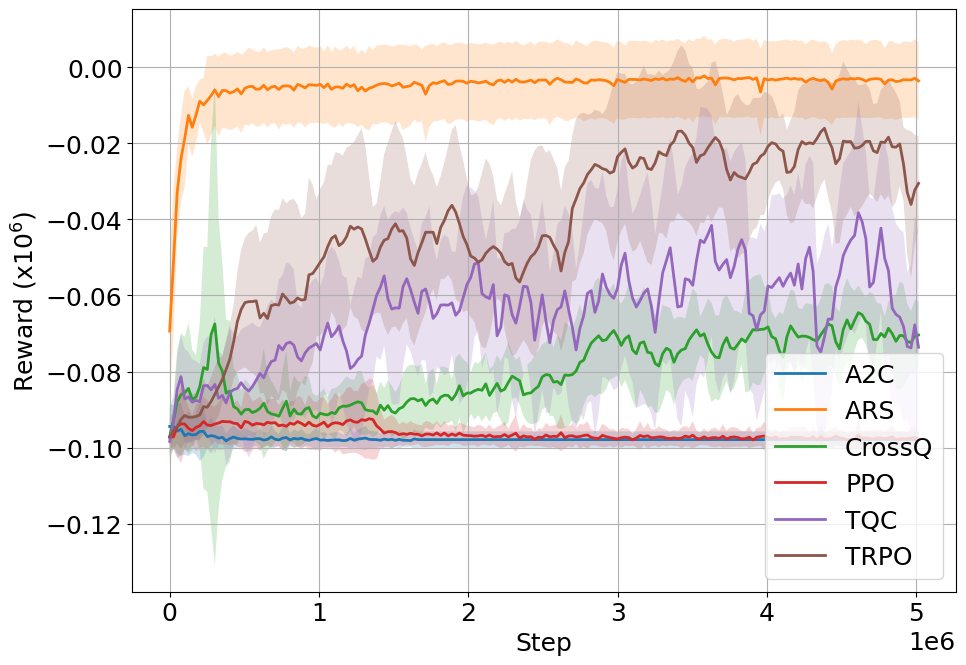

In [6]:
# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(rf"plots/wheeled_random_beocat_{date}.png")
plt.show()

In [7]:
a2c_df = df[df['algorithm']=='A2C']
ppo_df = df[df['algorithm']=='PPO']
trpo_df = df[df['algorithm']=='TRPO']
ars_df = df[df['algorithm']=='ARS']
crossq_df = df[df['algorithm']=='CrossQ']
tqc_df = df[df['algorithm']=='TQC']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-95972.176841,4539.168848,-70700.593750,30011.867188
1,AB,PPO,-96296.106243,4374.029843,-63067.281250,38479.843750
2,AB,TRPO,-44831.610361,27743.266093,16260.944336,118246.842773
3,AB,ARS,-5295.109548,12253.000202,18952.000000,107393.718750
4,AB,CrossQ,-83017.017639,19429.549611,115718.210938,216983.210938
5,AB,TQC,-71808.759080,24753.375397,14393.159180,117600.706055


In [8]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.095972,0.004539,-0.070701,0.030012
1,AB,PPO,-0.096296,0.004374,-0.063067,0.038480
2,AB,TRPO,-0.044832,0.027743,0.016261,0.118247
3,AB,ARS,-0.005295,0.012253,0.018952,0.107394
4,AB,CrossQ,-0.083017,0.019430,0.115718,0.216983
5,AB,TQC,-0.071809,0.024753,0.014393,0.117601


In [9]:
set_tab_df_sc.to_csv(rf"results/wheeled_random_beocat_results_{date}.csv")